In [23]:
import json
import pandas as pd
from pathlib import Path
from pydantic import BaseModel, ConfigDict
import datetime as datetime


class Date(BaseModel):
    year: int
    month: int
    day: int


class Config(BaseModel):
    model_config = ConfigDict(strict=True)
    latitude: float
    longitude: float
    radius: int
    limit: int
    sensor_name: str
    from_date: Date
    to_date: Date
    openaq_data_fp: str
    weather_data_fp: str


def load_config(config_fp: Path):
    """Load data load configuration from local JSON file.

    Args:
        config_fp (Path): Path to the configuration file in the repository.

    Returns:
        Config: Pydantic model.
    """
    try:
        with open(config_fp, "r") as f:
            json_content = json.loads(f.read())
            validated_model = Config.model_validate(json_content)

            return validated_model
    except Exception as e:
        print("Error occured:")
        print(e)

In [24]:
cfg = load_config(Path("../config/config.json"))

if not cfg:
    raise FileNotFoundError("Configuration could not be loaded.")

openaq_data = pd.read_parquet("../data/openaq.parquet")
openweather_data = pd.read_parquet("../data/weather.parquet")


In [37]:
openaq_data["timestamp"] = pd.to_datetime(openaq_data["coverage.datetime_from.utc"], utc=True)


In [41]:
openweather_data["timestamp"] = openweather_data["dt"].apply(lambda x: datetime.datetime.fromtimestamp(x, tz=datetime.timezone.utc))

In [57]:
ow = openweather_data[["timestamp", "temp"]]

In [58]:
oa = openaq_data[["timestamp", "value"]]

In [47]:
dt_idx = pd.date_range(
    start=datetime.datetime(2026, 1, 1),
    end=datetime.datetime(2026, 2, 1),
    freq="1h",
    tz=datetime.timezone.utc
)

In [49]:
df = pd.DataFrame(index=dt_idx)

In [78]:
merged_df = pd.merge(oa, ow, how="right", on="timestamp", left_index=False, right_index=False)

In [79]:
import seaborn as sns

<Axes: >

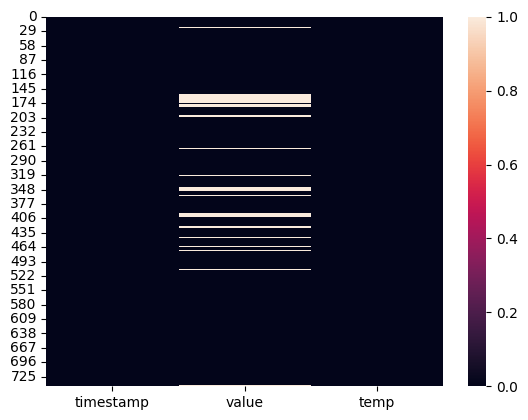

In [80]:
sns.heatmap(merged_df.isna())

In [81]:
merged_df.columns

Index(['timestamp', 'value', 'temp'], dtype='object')

In [82]:
merged_df[pd.isna(merged_df).any(axis=1)]

,timestamp,value,temp
14,2026-01-01 14:00:00+00:00,NaN,276.71
16,2026-01-01 16:00:00+00:00,NaN,275.03
21,2026-01-01 21:00:00+00:00,NaN,274.47
26,2026-01-02 02:00:00+00:00,NaN,274.67
61,2026-01-03 13:00:00+00:00,NaN,272.45
...,...,...,...
627,2026-01-27 03:00:00+00:00,NaN,272.10
655,2026-01-28 07:00:00+00:00,NaN,274.11
730,2026-01-31 10:00:00+00:00,NaN,277.56
743,2026-01-31 23:00:00+00:00,NaN,273.56


<Axes: >

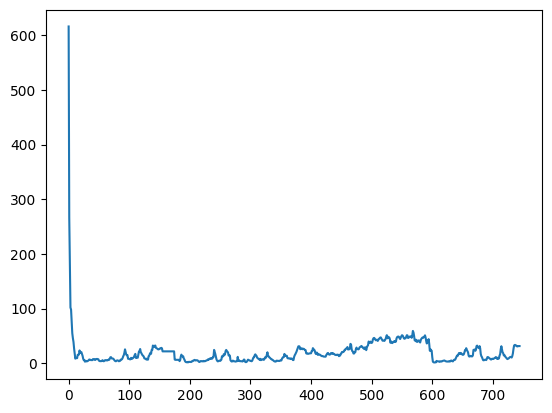

In [77]:
merged_df["value"].ffill().plot()